In [5]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plot_utils

In [4]:
start_date = pl.datetime(2009, 1, 1, time_zone="UTC")
end_date = pl.datetime(2022, 7, 1, time_zone="UTC")

starts = pl.datetime_range(start=start_date, end=end_date, interval="6mo", eager=True)

df_chunks = (
    pl.DataFrame({"chunk_id": range(1, len(starts) + 1), "start_date": starts})
    .with_columns(
        (pl.col("start_date").dt.offset_by("6mo") - pl.duration(seconds=1))
        .alias("end_date")
    )
)

print(df_chunks)

shape: (28, 3)
┌──────────┬─────────────────────────┬─────────────────────────┐
│ chunk_id ┆ start_date              ┆ end_date                │
│ ---      ┆ ---                     ┆ ---                     │
│ i64      ┆ datetime[μs, UTC]       ┆ datetime[μs, UTC]       │
╞══════════╪═════════════════════════╪═════════════════════════╡
│ 1        ┆ 2009-01-01 00:00:00 UTC ┆ 2009-06-30 23:59:59 UTC │
│ 2        ┆ 2009-07-01 00:00:00 UTC ┆ 2009-12-31 23:59:59 UTC │
│ 3        ┆ 2010-01-01 00:00:00 UTC ┆ 2010-06-30 23:59:59 UTC │
│ 4        ┆ 2010-07-01 00:00:00 UTC ┆ 2010-12-31 23:59:59 UTC │
│ 5        ┆ 2011-01-01 00:00:00 UTC ┆ 2011-06-30 23:59:59 UTC │
│ …        ┆ …                       ┆ …                       │
│ 24       ┆ 2020-07-01 00:00:00 UTC ┆ 2020-12-31 23:59:59 UTC │
│ 25       ┆ 2021-01-01 00:00:00 UTC ┆ 2021-06-30 23:59:59 UTC │
│ 26       ┆ 2021-07-01 00:00:00 UTC ┆ 2021-12-31 23:59:59 UTC │
│ 27       ┆ 2022-01-01 00:00:00 UTC ┆ 2022-06-30 23:59:59 UTC │
│ 28      

In [18]:
def read_stats(filename):
    result = {}
    with open(filename, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            try:
                value = int(value)
            except ValueError:
                try:
                    value = float(value)
                except ValueError:
                    pass
            result[key] = value
    return result

start_chunk = 1
end_chunk = 28
chunks = []
for i in range(start_chunk, end_chunk + 1):
    stats = read_stats(f"results/pg_{i}.stats")
    nodes = int(stats.get("nodes", 0))
    arcs = int(stats.get("arcs", 0))
    avg_in_degree = float(stats.get("avgindegree", 0.0))
    avg_out_degree = float(stats.get("avgoutdegree", 0.0))
    chunks.append({"chunk_id": i, "nodes": nodes, "arcs": arcs, "avg_in_degree": avg_in_degree, "avg_out_degree": avg_out_degree})

df_stats = pl.DataFrame(chunks).join(df_chunks, on="chunk_id", how="left").sort("chunk_id")
print(df_stats)

shape: (28, 7)
┌──────────┬────────────┬────────────┬───────────────┬───────────────┬──────────────┬──────────────┐
│ chunk_id ┆ nodes      ┆ arcs       ┆ avg_in_degree ┆ avg_out_degre ┆ start_date   ┆ end_date     │
│ ---      ┆ ---        ┆ ---        ┆ ---           ┆ e             ┆ ---          ┆ ---          │
│ i64      ┆ i64        ┆ i64        ┆ f64           ┆ ---           ┆ datetime[μs, ┆ datetime[μs, │
│          ┆            ┆            ┆               ┆ f64           ┆ UTC]         ┆ UTC]         │
╞══════════╪════════════╪════════════╪═══════════════╪═══════════════╪══════════════╪══════════════╡
│ 1        ┆ 18626      ┆ 1094       ┆ 0.058735      ┆ 0.058735      ┆ 2009-01-01   ┆ 2009-06-30   │
│          ┆            ┆            ┆               ┆               ┆ 00:00:00 UTC ┆ 23:59:59 UTC │
│ 2        ┆ 32781      ┆ 3628       ┆ 0.110674      ┆ 0.110674      ┆ 2009-07-01   ┆ 2009-12-31   │
│          ┆            ┆            ┆               ┆               ┆ 00:00

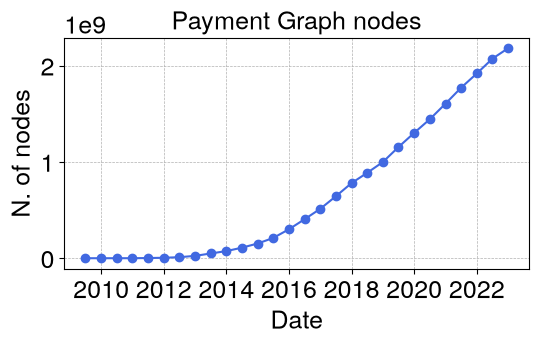

In [21]:
plt.figure(figsize=(6, 3))
plt.title('Payment Graph nodes')
plt.plot(df_stats['end_date'], df_stats['nodes'], color="royalblue", marker = 'o')
#plt.plot(df_stats['chunk_id'], df_stats['arcs'], color="red", marker = 'x')
plt.xlabel('Date')
plt.ylabel('N. of nodes')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.show()

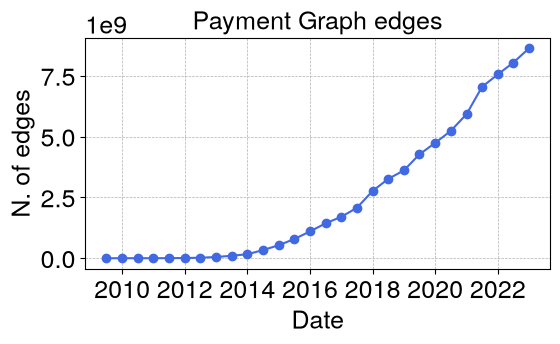

In [22]:
plt.figure(figsize=(6, 3))
plt.title('Payment Graph edges')
plt.plot(df_stats['end_date'], df_stats['arcs'], color="royalblue", marker = 'o')
plt.xlabel('Date')
plt.ylabel('N. of edges')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.show()

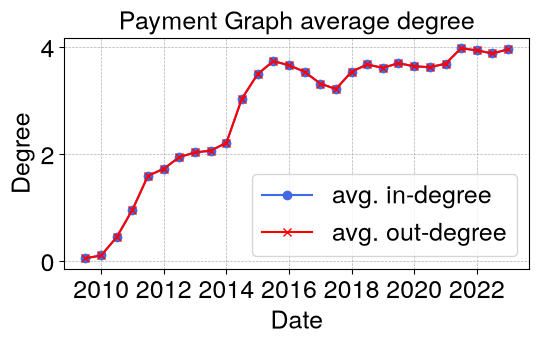

In [26]:
plt.figure(figsize=(6, 3))
plt.title('Payment Graph average degree')
plt.plot(df_stats['end_date'], df_stats['avg_in_degree'], color="royalblue", marker = 'o', label='avg. in-degree')
plt.plot(df_stats['end_date'], df_stats['avg_out_degree'], color="red", marker = 'x', label='avg. out-degree')
plt.xlabel('Date')
plt.ylabel('Degree')
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.legend()
plt.show()

In [2]:
def read_degree_distribution(filename):
    with open(filename, "r") as fh:
        counts = [int(line.strip()) for line in fh if line.strip()]
    return pl.DataFrame({"degree": range(len(counts)), "count": counts})

In [46]:
start_chunk = 1
end_chunk = 20
for i in range(start_chunk, end_chunk + 1):
    indegree_file = f"results/pg_{i}.indegree"
    outdegree_file = f"results/pg_{i}.outdegree"
    df_indegree = read_degree_distribution(indegree_file)
    df_outdegree = read_degree_distribution(outdegree_file)
    plt.figure(figsize=(3, 3))
    plt.title(f'Payment Graph {i}\nin-degree distribution')
    plt.scatter(df_indegree['degree'], df_indegree['count'], color="royalblue", marker = 'o')
    plt.xlabel('In-degree')
    plt.ylabel('Count')
    plt.xscale('symlog')
    plt.yscale('log')
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    plt.savefig(f"figures/pg_{i}_indegree.pdf", bbox_inches='tight')
    plt.close()
    plt.figure(figsize=(3, 3))
    plt.title(f'Payment Graph {i}\nout-degree distribution')
    plt.scatter(df_outdegree['degree'], df_outdegree['count'], color="crimson", marker = 'o')
    plt.xlabel('Out-degree')
    plt.ylabel('Count')
    plt.xscale('symlog')
    plt.yscale('log')
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    plt.savefig(f"figures/pg_{i}_outdegree.pdf", bbox_inches='tight')
    plt.close()


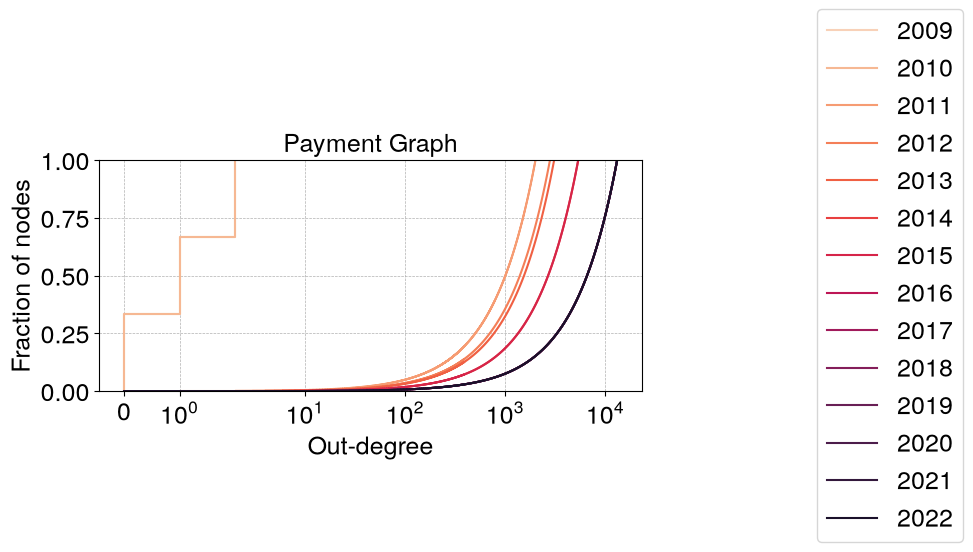

In [43]:
start_chunk = 2
end_chunk = 28
step = 2
plt.figure(figsize=(7, 3))
plt.title(f'Payment Graph')
plt.xlabel('Out-degree')
plt.ylabel('Fraction of nodes')
plt.xscale('symlog')
colors = sns.color_palette("rocket_r", n_colors=len(range(start_chunk, end_chunk + step, step)))

for color, i in zip(colors, range(start_chunk, end_chunk + step, step)):
    outdegree_file = f"results/pg_{i}.outdegree"
    df_outdegree = read_degree_distribution(outdegree_file)
    sns.ecdfplot(df_outdegree['degree'], label=str(2009 + (i - step) // step), color=color)
    
plt.legend(loc='center left', bbox_to_anchor=(1.3, 0.5))
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.savefig(f"figures/pg_temporal_outdegree.pdf", bbox_inches='tight')
plt.show()


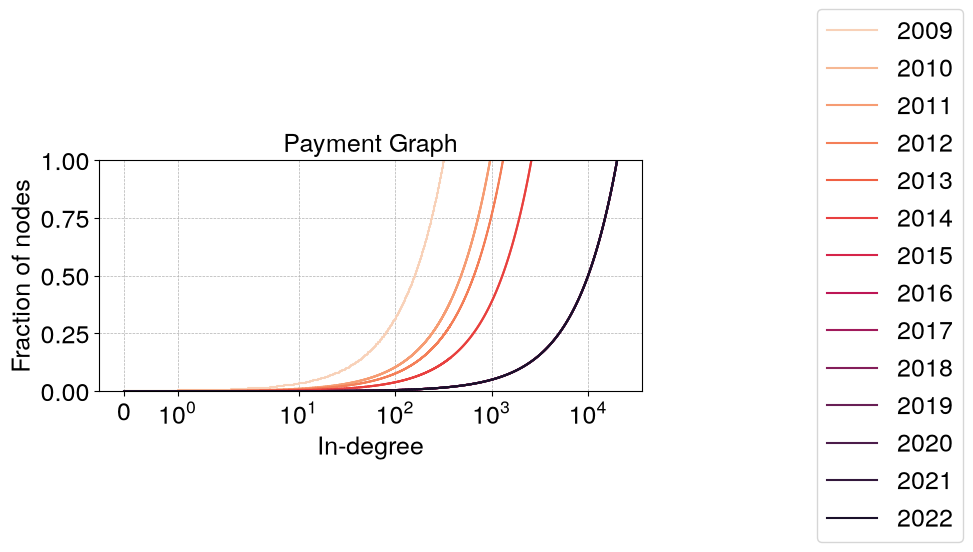

In [ ]:
start_chunk = 2
end_chunk = 28
step = 2
plt.figure(figsize=(7, 3))
plt.title(f'Payment Graph')
plt.xlabel('In-degree')
plt.ylabel('Fraction of nodes')
plt.xscale('symlog')
colors = sns.color_palette("rocket_r", n_colors=len(range(start_chunk, end_chunk + step, step)))

for color, i in zip(colors, range(start_chunk, end_chunk + step, step)):
    indegree_file = f"results/pg_{i}.indegree"
    df_indegree = read_degree_distribution(indegree_file)
    sns.ecdfplot(df_indegree['degree'], label=str(2009 + (i - step) // step), color=color)
    
plt.legend(loc='center left', bbox_to_anchor=(1.3, 0.5))
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
plt.savefig(f"figures/pg_temporal_indegree.pdf", bbox_inches='tight')
plt.show()